In [3]:
from stepmix.stepmix import StepMix
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
cluster_df = pd.read_csv("../../data/master_data/2016_to_2023_clustering_input_data.csv")

len(cluster_df)

85659

In [5]:
cluster_cols = ["Age9",
                "Gend3",
                "Eth7",
                "Disab2_POP",
                "Educ6",
                "NSSEC5",
                "IMD10",
                "WorkStat8",
                "Child4",
                "HHLiv9",
                "Motiva_POP",
                "motivd_POP"]

X = cluster_df[cluster_cols]

X.head()

,Age9,Gend3,Eth7,Disab2_POP,Educ6,NSSEC5,IMD10,WorkStat8,Child4,HHLiv9,Motiva_POP,motivd_POP
0,0,0,3,1,0,0,1,1,1,2,0,3
1,2,0,3,1,0,1,3,1,0,1,1,3
2,2,1,0,1,0,0,6,0,0,0,1,3
3,2,0,1,1,0,0,3,0,1,4,1,3
4,2,1,1,0,0,0,3,1,1,4,0,2


In [6]:
results = []

for k in range(20, 31):

    try:
    
        print(f"Fitting {k} classes...")

        model = StepMix(n_components=k,  measurement="categorical", random_state=42, n_init=10, max_iter=1000, abs_tol=1e-5)

        model.fit(X)

        proportions = model.predict_proba(X).mean(axis=0)

        results.append({"Classes": k,
                        "LogLik": model.score(X) * len(X),
                        "AIC": model.aic(X),
                        "BIC": model.bic(X),
                        "Converged": model.converged_,
                        "Iterations": model.n_iter_,
                        "MinClass": proportions.min(),
                        "MaxClass": proportions.max()})
        
    except Exception as e:
        results.append({"Classes": k, "Error": str(e)})

    pd.DataFrame(results).to_csv("latent_class_analysis_results.csv", index=False)

Fitting 20 classes...
Fitting StepMix...


Initializations (n_init) :   0%|          | 0/10 [00:00<?, ?it/s]

Initializations (n_init) : 100%|██████████| 10/10 [06:32<00:00, 39.27s/it, max_LL=-1.16e+6, max_avg_LL=-13.5]


Fitting 21 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [06:56<00:00, 41.62s/it, max_LL=-1.16e+6, max_avg_LL=-13.5]


...

Initializations (n_init) : 100%|██████████| 10/10 [07:15<00:00, 43.58s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


Fitting 29 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [07:35<00:00, 45.59s/it, max_LL=-1.15e+6, max_avg_LL=-13.5]


Fitting 30 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [08:23<00:00, 50.40s/it, max_LL=-1.15e+6, max_avg_LL=-13.4]


In [7]:
results_df = pd.DataFrame(results)

print(results_df)

    Classes        LogLik           AIC           BIC  Converged  Iterations  \
0        20 -1.156483e+06  2.315405e+06  2.326812e+06       True         252   
1        21 -1.156165e+06  2.314890e+06  2.326868e+06       True         209   
2        22 -1.155245e+06  2.313172e+06  2.325722e+06       True         262   
3        23 -1.154530e+06  2.311863e+06  2.324983e+06       True         340   
4        24 -1.154026e+06  2.310979e+06  2.324670e+06       True         228   
5        25 -1.153821e+06  2.310691e+06  2.324952e+06       True         224   
6        26 -1.153403e+06  2.309976e+06  2.324808e+06       True         107   
7        27 -1.152883e+06  2.309058e+06  2.324461e+06       True         185   
8        28 -1.152374e+06  2.308161e+06  2.324136e+06       True         281   
9        29 -1.152215e+06  2.307966e+06  2.324511e+06       True         154   
10       30 -1.151798e+06  2.307254e+06  2.324370e+06       True         195   

    MinClass  MaxClass  
0   0.005914  

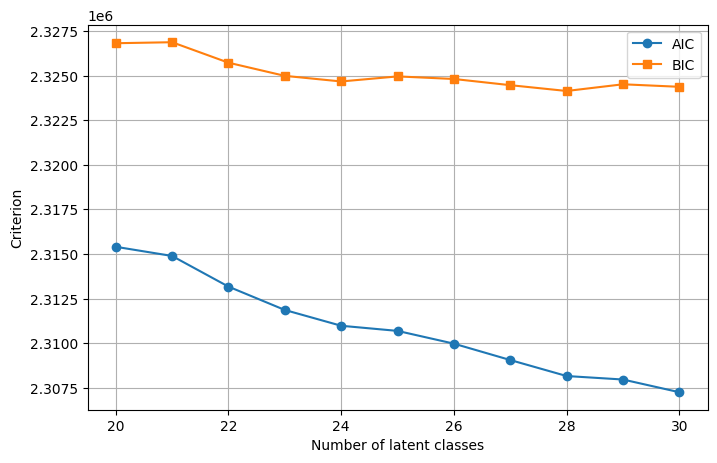

In [8]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Classes"],
         results_df["AIC"],
         marker="o",
         label="AIC")

plt.plot(results_df["Classes"],
         results_df["BIC"],
         marker="s",
         label="BIC")

plt.xlabel("Number of latent classes")
plt.ylabel("Criterion")

plt.legend()

plt.grid(True)

plt.show()